## Setup

### Import Required Packages

In [1]:
from recongraph.io_utils import file_writer, graph_generator
from recongraph.processors import graph_parser, graph_solver
from recongraph.visualizer import graph_visualizer
from pathlib import Path
import logging
from IPython.display import Image

In [2]:
logging.getLogger().setLevel(logging.DEBUG)
export_path = Path("../exports/")
if not export_path.exists():
    export_path.mkdir()

### Utility Functions

In [3]:
def viz_and_save(graph, path: Path, pos=None, bbox=None):
    file_writer.pygraphviz_export(graph, path.with_suffix(".pdf"))

    if not pos or not bbox:
        pass
        # pos, bbox = graph_visualizer.multipartite_layout_by_connections(graph)
        pos, bbox = graph_visualizer.pygraphviz_layout(graph)
    file_writer.inkscape_export(graph, path.with_suffix(".svg"), pos, bbox)
    # graph_visualizer.viz_dag(graph, pos)

In [4]:
import networkx as nx


def vis_graph(g):
    img, ag = nx.nx_agraph.view_pygraphviz(g, prog="dot", show=False)
    display(Image(filename=img))

In [5]:
import tempfile


def viz_agraph(g):
    ext = "png"
    suffix = f".{ext}"
    path = tempfile.NamedTemporaryFile(suffix=suffix, delete=False)

    # Write graph to file
    g.draw(path=path, prog='dot')
    path.close()

    display(Image(filename=path.name))

### Load Assembly

In [6]:
# Load Assembly
# assembly = graph_generator.graph_from_gh_csv("../assemblies/ReconSlab_Top-Connectivity.csv")
# assembly = graph_generator.graph_from_dot_file("../assemblies/simple.dot")
# assembly = nx.read_gml("../assemblies/exception2.gml")
# assembly = nx.read_gml("../assemblies/no_rdg.gml")
# assembly = graph_generator.graph_from_dot_file("../assemblies/simple.dot")
assembly = graph_generator.graph_from_dot_file("../assemblies/extended_scc.dot")
# assembly = nx.read_gml("../assemblies/extended.gml")

DEBUG    [recongraph.io_utils.graph_generator     ]::	NODE: a > TYPE: PART
DEBUG    [recongraph.io_utils.graph_generator     ]::	NODE: b > TYPE: PART
DEBUG    [recongraph.io_utils.graph_generator     ]::	NODE: c > TYPE: PART
DEBUG    [recongraph.io_utils.graph_generator     ]::	NODE: d > TYPE: PART
DEBUG    [recongraph.io_utils.graph_generator     ]::	NODE: e > TYPE: PART
DEBUG    [recongraph.io_utils.graph_generator     ]::	NODE: f > TYPE: PART
DEBUG    [recongraph.io_utils.graph_generator     ]::	NODE: g > TYPE: PART
DEBUG    [recongraph.io_utils.graph_generator     ]::	NODE: ab > TYPE: CONN
DEBUG    [recongraph.io_utils.graph_generator     ]::	NODE: ae > TYPE: CONN
DEBUG    [recongraph.io_utils.graph_generator     ]::	NODE: bc > TYPE: CONN
DEBUG    [recongraph.io_utils.graph_generator     ]::	NODE: bd > TYPE: CONN
DEBUG    [recongraph.io_utils.graph_generator     ]::	NODE: dg > TYPE: CONN
DEBUG    [recongraph.io_utils.graph_generator     ]::	NODE: ef > TYPE: CONN


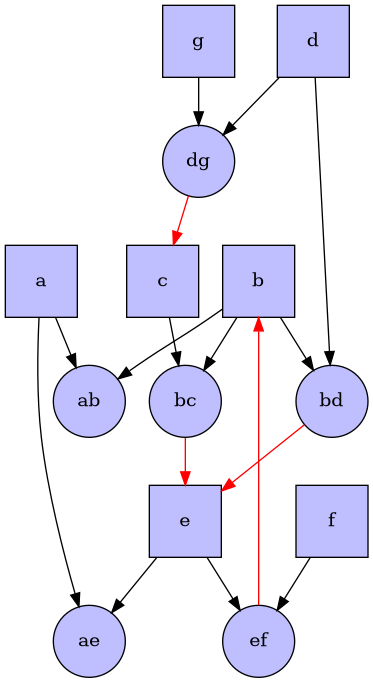

In [7]:
# viz_and_save(assembly, export_path / "01-dep.pdf")
vis_graph(assembly)

In [8]:
resolved = graph_solver.resolve_dependencies(assembly)

INFO     [recongraph.processors.graph_solver      ]::	Resolving Dependencies in a DiGraph named 'SIMPLE' with 13 nodes and 16 edges
DEBUG    [recongraph.processors.graph_solver      ]::	Found a SCC of 5 Nodes > {'e', 'ef', 'b', 'bd', 'bc'}
DEBUG    [recongraph.processors.graph_solver      ]::		Including 3 connected parts > ['c', 'd', 'f']
INFO     [recongraph.processors.graph_solver      ]::		Collapsing Nodes into Cluster -1 with Cluster Level: 0 > NODES: ['b', 'c', 'd', 'e', 'f', 'bc', 'bd', 'ef']
DEBUG    [recongraph.processors.graph_solver      ]::		Found new SCC including the extended nodes: [-1, 'dg']
DEBUG    [recongraph.processors.graph_solver      ]::		Extending subgraph to new SCC with 1 nodes > ['dg']
DEBUG    [recongraph.processors.graph_solver      ]::		Including 1 connected parts > ['g']
INFO     [recongraph.processors.graph_solver      ]::		Collapsing Nodes into Cluster -1 with Cluster Level: 0 > NODES: ['b', 'c', 'd', 'e', 'f', 'g', 'bc', 'bd', 'dg', 'ef']
DEBUG    [reco

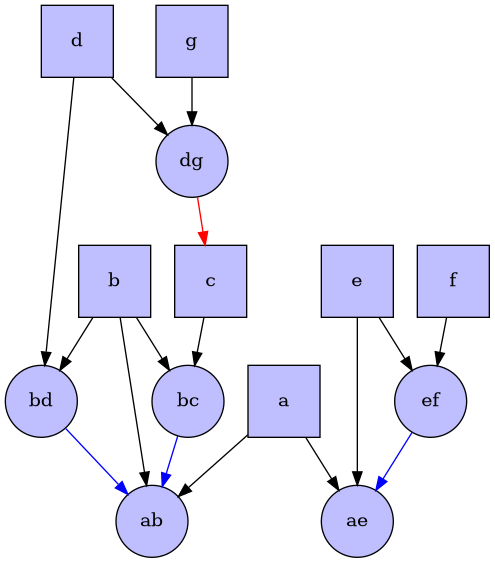

In [9]:
# viz_and_save(resolved, export_path / "RESOLVED.pdf")
vis_graph(resolved)

### Stages

In [10]:
stages = graph_parser.add_stages(resolved)
components = graph_parser.add_components(resolved)

print(stages)
print(components)

DEBUG    [recongraph.processors.graph_parser      ]::	Longest Path Length: 2
INFO     [recongraph.processors.graph_parser      ]::	Generated 3 earliest stages > # of connections in each stage: [3, 2, 1]
INFO     [recongraph.processors.graph_parser      ]::	Generated 3 latest stages   > # of connections in each stage: [1, 3, 2]
DEBUG    [recongraph.processors.graph_parser      ]::	Node: a > Stage: 1 => 2
DEBUG    [recongraph.processors.graph_parser      ]::	Node: b > Stage: 0 => 1
DEBUG    [recongraph.processors.graph_parser      ]::	Node: c > Stage: 1 => 1
DEBUG    [recongraph.processors.graph_parser      ]::	Node: d > Stage: 0 => 0
DEBUG    [recongraph.processors.graph_parser      ]::	Node: e > Stage: 0 => 1
DEBUG    [recongraph.processors.graph_parser      ]::	Node: f > Stage: 0 => 1
DEBUG    [recongraph.processors.graph_parser      ]::	Node: g > Stage: 0 => 0
DEBUG    [recongraph.processors.graph_parser      ]::	Found 3 stages > [0, 1, 2]
DEBUG    [recongraph.processors.graph_parser

range(0, 3)
{0: [0], 1: [0, 1], 2: [0]}


# Drafts

In [15]:
nx.minimum_node_cut(assembly, "d", "e")

{'bc', 'bd'}

In [23]:
kir = assembly.copy()

for e in kir.edges:
    kir[e[0]][e[1]]['capacity'] = 1

In [34]:
nx.minimum_cut(kir, 'b', 'ef')

(1,
 ({'a', 'ab', 'ae', 'b', 'bc', 'bd', 'c', 'd', 'dg', 'e', 'g'}, {'ef', 'f'}))